### Calculating the QM solution of the reaction between $OH^-$ and $CH_3Cl$

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyscf import gto, scf
from pyscf.geomopt.geometric_solver import optimize
import pickle

In [2]:
def move_oh_to_distance(coords, target_distance):

    coords = coords.copy()

    O = 0
    H_oh = 1
    C = 2

    carbon = coords[C]
    oxygen = coords[O]

    # Current direction from C toward O
    direction = oxygen - carbon
    direction /= np.linalg.norm(direction)

    # Preserve the O-H vector
    oh_vector = coords[H_oh] - coords[O]

    # Place O at the desired C-O distance
    new_oxygen = carbon + direction * target_distance

    # Move H together with O
    new_hydrogen = new_oxygen + oh_vector

    coords[O] = new_oxygen
    coords[H_oh] = new_hydrogen

    return coords

def build_molecule(coords):

    atom_string = ""

    for symbol, coord in zip(symbols, coords):

        x, y, z = coord

        atom_string += (
            f"{symbol} "
            f"{x:.10f} "
            f"{y:.10f} "
            f"{z:.10f}\n"
        )

    return gto.M(
        atom=atom_string,
        basis="6-31G",
        charge=-1,
        spin=0,
        unit="Angstrom"
    )
    
def write_constraint(distance):

    with open("constraints.txt", "w") as f:

        f.write("$set\n")
        f.write(
            f"distance 1 3 {distance:.8f}\n"
        )

def make_scf(mol):

    mf = scf.RHF(mol)
    return mf
    
def optimize_at_distance(mol, distance, maxsteps=15):

    # Create the constraint file
    write_constraint(distance)

    # Build RHF + implicit solvent
    mf = make_scf(mol)

    # Optimize geometry while keeping C-O fixed
    mol_opt = optimize(
        mf,
        constraints="constraints.txt",
        maxsteps=maxsteps
    )

    # Recalculate final energy using the optimized geometry
    mf_final = make_scf(mol_opt)
    energy = mf_final.kernel()

    # Return the optimized geometry and energy
    return mol_opt, energy, mf_final

def write_xyz(mol, filename, distance):

    coords = mol.atom_coords(
        unit="Angstrom"
    )

    with open(filename, "w") as f:

        f.write(f"{mol.natm}\n")

        f.write(
            f"C-O distance = {distance:.8f} Angstrom\n"
        )

        for symbol, coord in zip(symbols, coords):

            x, y, z = coord

            f.write(
                f"{symbol:2s} "
                f"{x:14.8f} "
                f"{y:14.8f} "
                f"{z:14.8f}\n"
            )


In [3]:
initial_xyz = """
O   -5.000   0.000   0.000
H   -5.970   0.000   0.000

C    0.000   0.000   0.000
Cl   1.780   0.000   0.000

H   -0.630   0.630   0.630
H   -0.630  -0.630   0.630
H   -0.630   0.000  -0.890
"""

In [4]:
symbols = [
    "O",
    "H",
    "C",
    "Cl",
    "H",
    "H",
    "H"
]

In [5]:
mol = gto.M(
    atom=initial_xyz,
    basis="6-31G",
    charge=-1,
    spin=0,
    unit="Angstrom"
)

In [6]:
ndistances = 5
distances = np.linspace(3.0, 1.2, ndistances)

print("Number of steps:", len(distances))
print("Starting distance:", distances[0])
print("Final distance:", distances[-1])

Number of steps: 5
Starting distance: 3.0
Final distance: 1.2


In [7]:
os.makedirs("xyz_frames", exist_ok=True)
for f in glob.glob("xyz_frames/frame_*.xyz"):
    os.remove(f)

print("XYZ folder cleared.")

XYZ folder cleared.


In [8]:
energies = []
actual_distances = []
optimized_molecules = []
mean_field_objects = []

current_mol = mol

In [9]:
for i, distance in enumerate(distances):

    print("=" * 70)
    print(f"FRAME {i+1}/"+str(ndistances))
    print(f"Target C-O distance: {distance:.6f} Å")

    # ------------------------------------------------
    # 1. Get previous optimized geometry
    # ------------------------------------------------

    current_coords = current_mol.atom_coords(
        unit="Angstrom"
    )

    # ------------------------------------------------
    # 2. Move OH- to the next reaction-coordinate value
    # ------------------------------------------------

    current_coords = move_oh_to_distance(
        current_coords,
        distance
    )

    # ------------------------------------------------
    # 3. Rebuild PySCF molecule
    # ------------------------------------------------

    current_mol = build_molecule(
        current_coords
    )

    # ------------------------------------------------
    # 4. Constrained solvated optimization
    # ------------------------------------------------

    current_mol, energy, mf = optimize_at_distance(
        current_mol,
        distance)
    
    # ------------------------------------------------
    # 5. Store optimized molecule, energy, and mean field
    # ------------------------------------------------

    optimized_molecules.append(current_mol)
    energies.append(energy)
    mean_field_objects.append(mf)
    
    # ------------------------------------------------
    # 6. Calculate actual C-O distance
    # ------------------------------------------------

    optimized_coords = current_mol.atom_coords(
        unit="Angstrom"
    )

    actual_distance = np.linalg.norm(
        optimized_coords[0] -
        optimized_coords[2]
    )

    actual_distances.append(
        actual_distance
    )

    # ------------------------------------------------
    # 7. Save XYZ
    # ------------------------------------------------

    filename = (
        f"xyz_frames/frame_{i:03d}.xyz"
    )

    write_xyz(
        current_mol,
        filename,
        actual_distance
    )

    # ------------------------------------------------
    # 8. Report
    # ------------------------------------------------

    print(
        f"Actual C-O: "
        f"{actual_distance:.6f} Å"
    )

    print(
        f"Energy: "
        f"{energy:.10f} Hartree"
    )

    print(
        f"Saved: {filename}"
    )

geometric-optimize called with the following command line:
/home/chemistry/venvs/jupyter/lib/python3.14/site-packages/ipykernel_launcher.py -f /home/chemistry/.local/share/jupyter/runtime/kernel-ae54a30c-a9f2-4761-9493-4eb53a063ab3.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%/      *%%%%%%,  **

FRAME 1/5
Target C-O distance: 3.000000 Å

Geometry optimization cycle 1
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -3.000000   0.000000   0.000000    0.000000  0.000000  0.000000
   H  -3.970000   0.000000   0.000000    0.000000  0.000000  0.000000
   C   0.000000   0.000000   0.000000    0.000000  0.000000  0.000000
  Cl   1.780000   0.000000   0.000000    0.000000  0.000000  0.000000
   H  -0.630000   0.630000   0.630000    0.000000  0.000000  0.000000
   H  -0.630000  -0.630000   0.630000    0.000000  0.000000  0.000000
   H  -0.630000   0.000000  -0.890000    0.000000  0.000000  0.000000

WARN: Mole.unit (Angstrom) is changed to Bohr

converged SCF energy = -574.337428057699
--------------- RHF_Scanner gradients ---------------
         x                y                z
0 O    -0.0121572510    -0.0000000000    -0.0018561992
1 H    -0.0004407791     0.0000000000    -0.0006339463
2 C     0.1137277187    -0.0000000000    -

Step    0 : Gradient = 5.282e-02/9.287e-02 (rms/max) Energy = -574.3374280577
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 3.46752e-01 3.47392e-01 5.01282e-01



Geometry optimization cycle 2
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -3.025533   0.000000   0.009343   -0.025533  0.000000  0.009343
   H  -3.990991  -0.000000   0.002801   -0.020991 -0.000000  0.002801
   C  -0.027512  -0.000000   0.050466   -0.027512 -0.000000  0.050466
  Cl   1.754677   0.000000   0.016289   -0.025323  0.000000  0.016289
   H  -0.578000   0.794813   0.580392    0.052000  0.164813 -0.049608
   H  -0.578000  -0.794813   0.580392    0.052000 -0.164813 -0.049608
   H  -0.564855  -0.000000  -0.887899    0.065145 -0.000000  0.002101
converged SCF energy = -574.377429061093
--------------- RHF_Scanner gradients ---------------
         x                y                z
0 O    -0.0154500398     0.0000000000    -0.0006171295
1 H     0.0052859221     0.0000000000    -0.0001294816
2 C     0.1079423189     0.0000000000    -0.0203280110
3 Cl    -0.0159189133    -0.0000000000    -0.0016448160
4 H    -0.0308858950 

Step    1 : Displace = 1.025e-01/1.768e-01 (rms/max) Trust = 1.000e-01 (=) Grad_T = 3.954e-02/8.920e-02 (rms/max) E (change) = -574.3774290611 (-4.000e-02) Quality = 0.909
Constraint                         Current      Target       Diff.
Distance 1-3                       2.99830     3.00000    -0.00170
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 3.46752e-01 3.91340e-01 5.01067e-01


...


Geometry optimization cycle 15
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -1.674347   0.214671   0.353623    0.092744  0.151709  0.022098
   H  -1.417227   0.348115   1.256191    0.199133 -0.158058  0.103957
   C  -0.825475  -0.181957  -0.396111    0.006654  0.022205 -0.024437
  Cl   2.435983   0.619367   1.784514   -0.215435  0.054017  0.057598
   H   0.201854   0.149278  -0.170269    0.083301 -0.065256 -0.123388
   H  -0.781854  -1.272211  -0.472202   -0.145340  0.008675 -0.007003
   H  -0.972552   0.122741  -1.438443   -0.021056 -0.013292 -0.028826
converged SCF energy = -574.471926256037
--------------- RHF_Scanner gradients ---------------
         x                y                z
0 O     0.2088243474    -0.1042750453    -0.1902497417
1 H     0.0021658811    -0.0022084968    -0.0006990855
2 C    -0.2197879566     0.0975980422     0.1928717176
3 Cl     0.0026255886     0.0000699532    -0.0001853144
4 H     0.0069670709

Step   14 : Displace = 1.729e-01/2.671e-01 (rms/max) Trust = 3.000e-01 (=) Grad_T = 6.855e-03/9.279e-03 (rms/max) E (change) = -574.4719262560 (-2.085e-03) Quality = 1.471
Hessian Eigenvalues: 1.31813e-03 2.35633e-02 5.00000e-02 ... 5.85976e-01 6.54448e-01 1.05182e+00



Geometry optimization cycle 16
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -1.494286   0.382315   0.396983    0.180061  0.167644  0.043360
   H  -1.260994   0.228068   1.305354    0.156233 -0.120047  0.049163
   C  -0.799625  -0.175437  -0.406982    0.025849  0.006520 -0.010870
  Cl   2.187922   0.718631   1.788641   -0.248061  0.099264  0.004127
   H   0.289498  -0.032639  -0.272916    0.087643 -0.181918 -0.102647
   H  -0.967465  -1.257099  -0.456831   -0.185610  0.015112  0.015371
   H  -0.988669   0.136166  -1.436946   -0.016116  0.013424  0.001497
converged SCF energy = -574.471980996677
--------------- RHF_Scanner gradients ---------------
         x                y                z
0 O     0.1701180275    -0.1340654432    -0.2033723330
1 H    -0.0001806304    -0.0100096529    -0.0006916409
2 C    -0.1815869694     0.1353288718     0.2057077951
3 Cl     0.0022739778     0.0010776667    -0.0010237295
4 H     0.0105833987

Step   15 : Displace = 1.925e-01/2.815e-01 (rms/max) Trust = 3.000e-01 (=) Grad_T = 8.814e-03/1.133e-02 (rms/max) E (change) = -574.4719809967 (-5.474e-05) Quality = 0.046
Hessian Eigenvalues: 1.31813e-03 2.35633e-02 5.00000e-02 ... 5.85976e-01 6.54448e-01 1.05182e+00
Maximum iterations reached (15); increase --maxiter for more


Geometry optimization failed to converge in 15 iterations
converged SCF energy = -574.471980996676
Actual C-O: 1.200000 Å
Energy: -574.4719809967 Hartree
Saved: xyz_frames/frame_004.xyz


### Visualizing some results

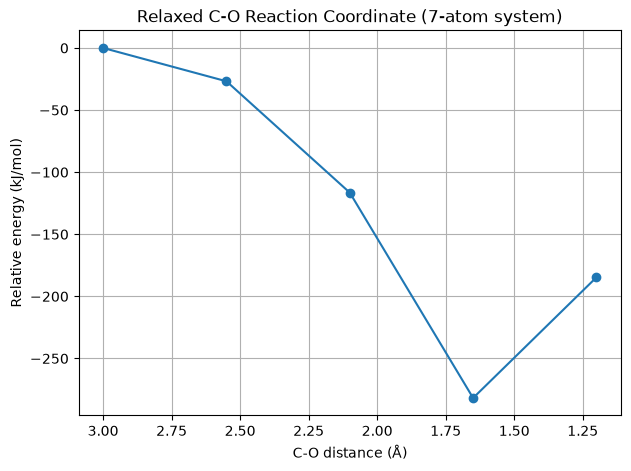

In [13]:
# Looking at the energies
energies_kj=(energies-energies[0])*2626
plt.figure(figsize=(7,5))
plt.plot(actual_distances,energies_kj,marker="o")
plt.gca().invert_xaxis()
xlabel = "C-O distance (Å)"; plt.xlabel(xlabel)
ylabel = "Relative energy (kJ/mol)"
plt.ylabel(ylabel)
plt.title("Relaxed C-O Reaction Coordinate (7-atom system)")
plt.grid(True)
plt.show()

### Saving additional results

In [14]:
# Saves the optimized molecule objects
with open("optimized_mols.pkl", "wb") as f:
    pickle.dump(optimized_molecules, f)

with open("optimized_mfs.pkl", "wb") as f:
    pickle.dump(mean_field_objects, f)
    
# Save the relative energies as a text file
data = np.array([actual_distances,energies_kj]).T; print(np.shape(data))
np.savetxt('energy.txt',data,header=xlabel+', '+ylabel)

# Save the absolute energies as a text file
data = np.array([actual_distances,energies]).T; print(np.shape(data))
np.savetxt('energy_abs.txt',data,header=xlabel+', '+"Relative energy (Hartree)")

(5, 2)
(5, 2)
